# 풋옵션의 payoff 그리기

옵션 현재가치:  9.354197236057225
옵션의 세타: -0.009164500752003785


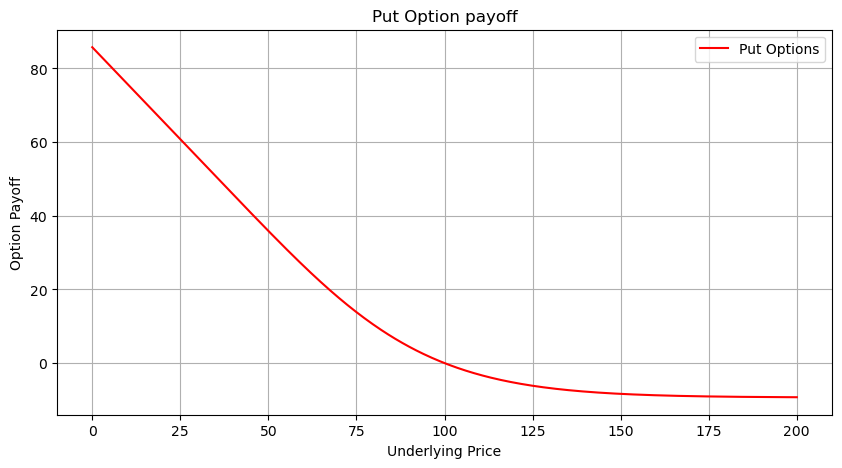

In [18]:
from hst_funcs.finanace.Equity import BS
import numpy as np
import matplotlib.pyplot as plt

# 파라미터 설정
S_max = 200
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.3
N = 500 # 기초자산 격자

opt_values = np.zeros(N+1)
opt_payoff = np.zeros(N+1)

opt0 = BS.bs_put(S0, K, T, r, sigma)
print('옵션 현재가치: ', opt0)
theta = BS.put_theta(S0, K, T, r, sigma)
print('옵션의 세타:',theta)

S = np.linspace(0.001, S_max, N+1)

for i,s in enumerate(S):
    opt_values[i]=BS.bs_put(s, K, T, r, sigma)

# 하루 뒤의 option payoff
opt_payoff=opt_values-opt0-theta

plt.figure(figsize=(10, 5))
plt.plot(S, opt_payoff, 'r', label='Put Options')
plt.xlabel('Underlying Price')
plt.ylabel('Option Payoff')
plt.legend()
plt.title("Put Option payoff")
plt.grid(True)
plt.show()

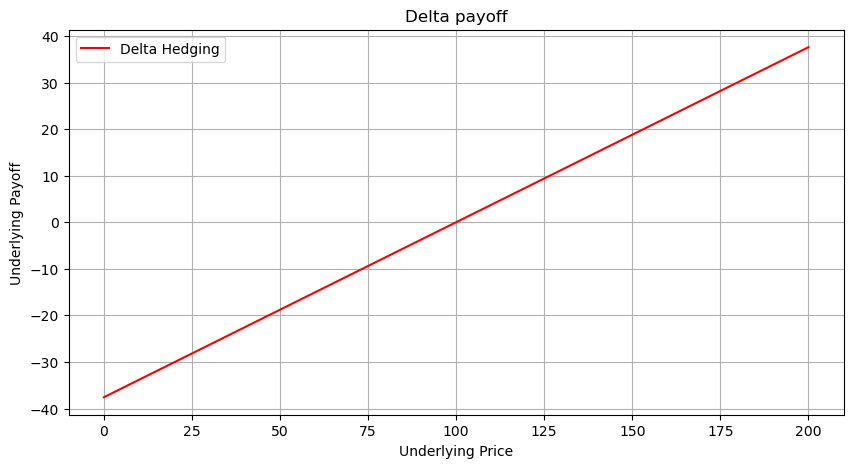

In [19]:
# with delta hedgaing
delta_payoff = np.zeros(N+1)
delta = BS.put_delta(S0, K, T, r, sigma)
delta_payoff = (S - S0) * (-delta)

plt.figure(figsize=(10, 5))
plt.plot(S, delta_payoff, 'r', label='Delta Hedging')
plt.xlabel('Underlying Price')
plt.ylabel('Underlying Payoff')
plt.legend()
plt.title("Delta payoff")
plt.grid(True)
plt.show()

옵션 현재가치:  9.354197236057225
옵션의 세타: -0.009164500752003785


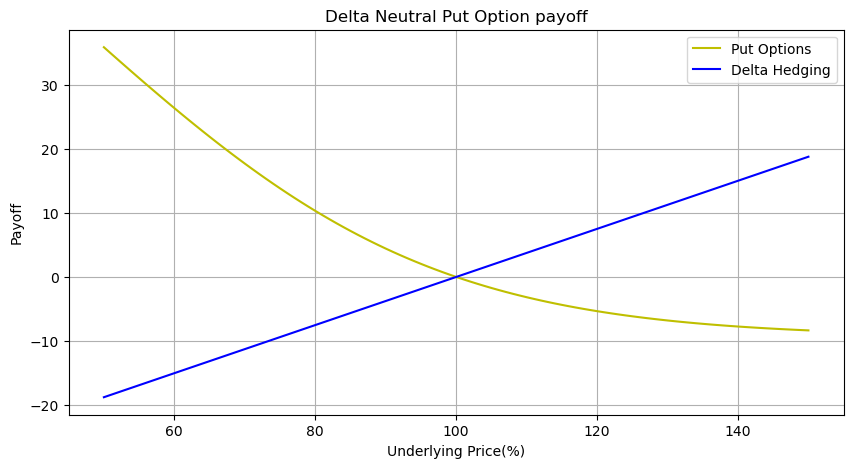

In [91]:
# 합성 payoff

from hst_funcs.finanace.Equity import BS
import numpy as np
import matplotlib.pyplot as plt

plimit=0.5

# 가격의 최소값과 최대값을 계산
min_price = S0 * (1 - plimit)
max_price = S0 * (1 + plimit)

# min_price와 max_price 사이에서 N개의 가격을 균등하게 생성
S = np.linspace(min_price, max_price, N+1)

opt_values = np.zeros(N+1)
opt_payoff = np.zeros(N+1)

opt0 = BS.bs_put(S0, K, T, r, sigma)
print('옵션 현재가치: ', opt0)
theta = BS.put_theta(S0, K, T, r, sigma)
print('옵션의 세타:',theta)



# with delta hedgaing
delta_payoff = np.zeros(N+1)
delta = BS.put_delta(S0, K, T, r, sigma)
delta_payoff = (S - S0) * (-delta)


for i,s in enumerate(S):
    opt_values[i]=BS.bs_put(s, K, T, r, sigma)

# 하루 뒤의 option payoff
opt_payoff=opt_values-opt0-theta


plt.figure(figsize=(10, 5))
plt.plot(S, opt_payoff, 'y', label='Put Options')
plt.plot(S, delta_payoff, 'b-', label='Delta Hedging')
plt.xlabel('Underlying Price(%)')
plt.ylabel('Payoff')
plt.legend()
plt.title("Delta Neutral Put Option payoff")
plt.grid(True)
plt.show()


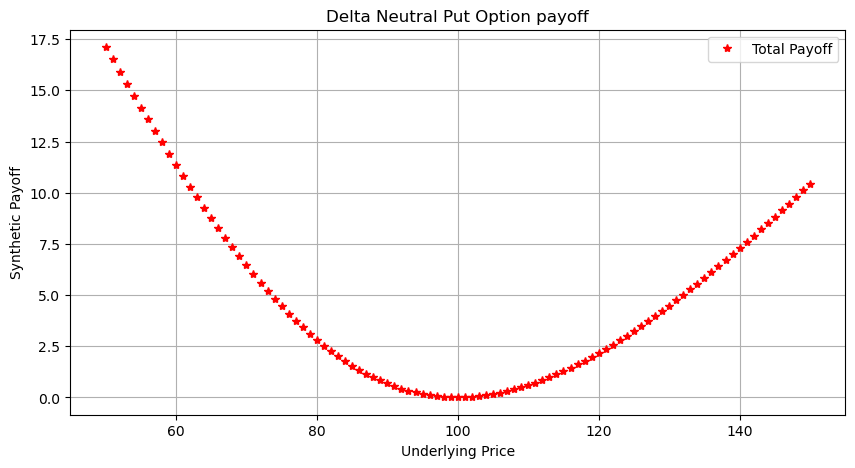

In [92]:
# 합성 payoff

# with delta hedgaing
total_payoff = np.zeros(N+1)
total_payoff= delta_payoff+opt_payoff

plt.figure(figsize=(10, 5))
plt.plot(S, total_payoff, 'r*', label='Total Payoff')
plt.xlabel('Underlying Price')
plt.ylabel('Synthetic Payoff')
plt.legend()
plt.title("Delta Neutral Put Option payoff")
plt.grid(True)
plt.show()

옵션 현재가치:  9.354197236057225
옵션의 세타: -0.009164500752003785


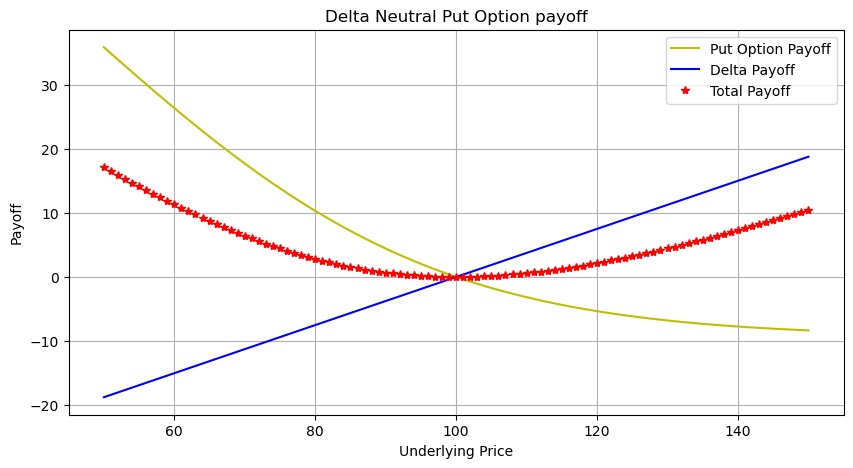

In [93]:
# 합성 payoff

from hst_funcs.finanace.Equity import BS
import numpy as np
import matplotlib.pyplot as plt

plimit=0.5

# 가격의 최소값과 최대값을 계산
min_price = S0 * (1 - plimit)
max_price = S0 * (1 + plimit)

# min_price와 max_price 사이에서 N개의 가격을 균등하게 생성
S = np.linspace(min_price, max_price, N+1)


opt_values = np.zeros(N+1)
opt_payoff = np.zeros(N+1)

opt0 = BS.bs_put(S0, K, T, r, sigma)
print('옵션 현재가치: ', opt0)
theta = BS.put_theta(S0, K, T, r, sigma)
print('옵션의 세타:',theta)

# with delta hedgaing
delta_payoff = np.zeros(N+1)
delta = BS.put_delta(S0, K, T, r, sigma)
delta_payoff = (S - S0) * (-delta)


for i,s in enumerate(S):
    opt_values[i]=BS.bs_put(s, K, T, r, sigma)

# 하루 뒤의 option payoff
opt_payoff=opt_values-opt0-theta

# 종합 payoff
total_payoff = np.zeros(N+1)
total_payoff= delta_payoff+opt_payoff

plt.figure(figsize=(10, 5))
plt.plot(S, opt_payoff, 'y', label='Put Option Payoff')
plt.plot(S, delta_payoff, 'b-', label='Delta Payoff')
plt.plot(S, total_payoff, 'r*', label='Total Payoff')
plt.xlabel('Underlying Price')
plt.ylabel('Payoff')
plt.legend()
plt.title("Delta Neutral Put Option payoff")
plt.grid(True)
plt.show()


# 여러 자산의 payoff

In [73]:
# options
options = np.array([['p',100,1,0.05,0.3],['c',100,1,0.05,0.35]])
M=len(options)

for m in range(M):
    if options[m][0] == 'p':
        K, T, r, sigma = options[m][1:].astype(float)  # 숫자로 변환
        print('풋옵션의 가격: ',BS.bs_put(S0,K,T,r,sigma))
    elif options[m][0] == 'c':
        K, T, r, sigma = options[m][1:].astype(float)  # 숫자로 변환
        print('콜옵션의 가격: ',BS.bs_call(S0,K,T,r,sigma))

풋옵션의 가격:  9.354197236057225
콜옵션의 가격:  16.12842888157588


In [100]:
# pip install hst_funcs 로 패키지 설치
from hst_funcs.finanace.Equity import BS

# 파라미터 설정
S0 = 100 # 기초자산현재가 
K = 100 # 행사가격
T = 1.0 # 옵션만기 (in years)
r = 0.05 # 무위험이자율(%)
sigma = 0.3 # 기초자산의 년변동성 (30%)

# 풋옵션의 가격
BS.bs_put(S0, K, T, r, sigma)

9.354197236057225

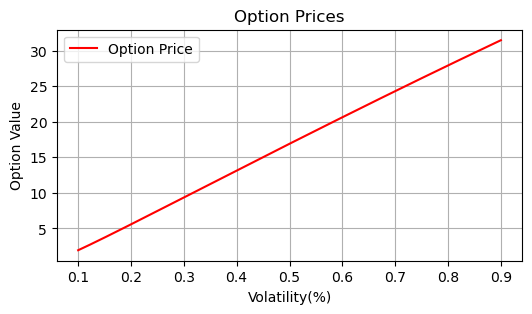

In [104]:
# 변동성 변화에 따른 가격 변화 그래프
sigmas=np.linspace(0.1,0.9,1000)
Opt=np.zeros(len(sigmas))
for i,sig in enumerate(sigmas):
    Opt[i]=BS.bs_put(S0, K, T, r, sig)

plt.figure(figsize=(6, 3))
plt.plot(sigmas, Opt, 'r', label='Option Price')
plt.xlabel('Volatility(%)')
plt.ylabel('Option Value')
plt.legend()
plt.title("Option Prices")
plt.grid(True)
plt.show()

In [106]:
# 동일한 옵션을 싸게 매수하고, 비싸게 매도한 경우
opt_buy = BS.bs_put(S0, K, T, r, sigma)
opt_sell = BS.bs_put(S0, K, T, r, sigma+0.05)
print('매수한 옵션의 가격:',opt_buy)
print('매도한 옵션의 가격:',opt_sell)
print('확정수익:',opt_sell - opt_buy)

매수한 옵션의 가격: 9.354197236057225
매도한 옵션의 가격: 11.251371331647285
확정수익: 1.89717409559006


-0.009164500752003785 -0.37574827209398753
-0.011570127478143545 -0.3536148917288414
-0.02348973929231711 0.4741018883101451
-0.02348973929231711 0.4741018883101451
-0.023025297639325933 0.37852913650867154
-0.023100437026532316 0.3153860516278818


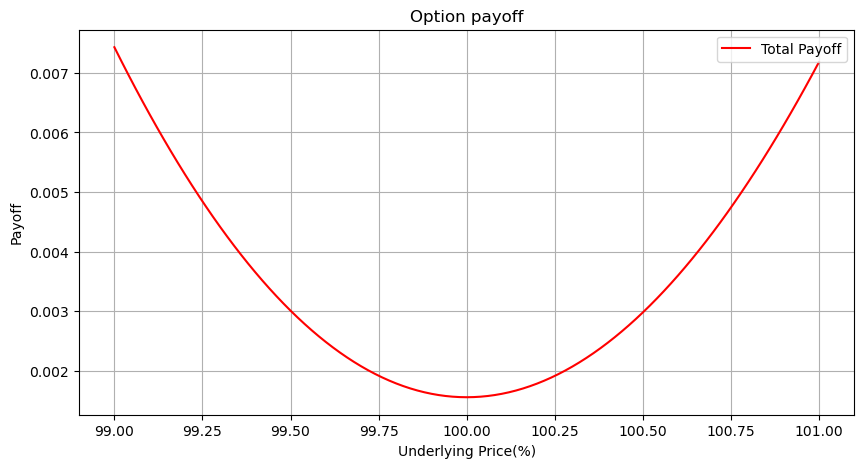

In [113]:
plimit,N=0.01,100 # 10%

# 가격의 최소값과 최대값을 계산
min_price = S0 * (1 - plimit)
max_price = S0 * (1 + plimit)

# min_price와 max_price 사이에서 N개의 가격을 균등하게 생성
prices = np.linspace(min_price, max_price, N+1)

# options
options = np.array([['p',1,100,1,0.05,0.3],
                    ['p',-1,98,1,0.05,0.35],
                    ['c', 1,105,0.5,0.05,0.23],
                    ['c', 1,105,0.5,0.05,0.23],
                    ['c',-1,110,0.5,0.05,0.25],
                    ['c',-1,115,0.5,0.05,0.28],
                   ])

M=len(options) # 옵션의 개수


# payoff 저장공간
opt_values = np.zeros([M, N+1])  # 옵션 가격을 저장할 배열
opt_payoff = np.zeros([M, N+1])  # 옵션 페이오프를 저장할 배열
delta_payoff = np.zeros([M, N+1])  # 델타 페이오프를 저장할 배열
total_payoff = np.zeros([M, N+1])  # 전체 페이오프를 저장할 배열

for m in range(M):
    if options[m][0] == 'p':
        buysell = options[m][1].astype(float)
        K, T, r, sigma = options[m][2:].astype(float)  # 숫자로 변환
        
        # 옵션 가격 및 그리스 계산
        opt0 = BS.bs_put(S0, K, T, r, sigma)
        theta = BS.put_theta(S0, K, T, r, sigma)
        delta = BS.put_delta(S0, K, T, r, sigma)
        print(theta,delta)
        
        # 가격대별로 옵션 가격 계산
        for i, s in enumerate(prices):
            opt_values[m, i] = BS.bs_put(s, K, T, r, sigma)
        
        if buysell == 1: # 옵션매수이면
            # delta_payoff 계산
            delta_payoff[m,:] = (prices - S0) * (-delta) 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = opt_values[m, :] - opt0 + theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]
        elif buysell == -1: # 옵션매도이면
            # delta_payoff 계산
            delta_payoff[m,:] =  (prices - S0) * delta 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = - (opt_values[m, :] - opt0) - theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]

    elif options[m][0] == 'c':
        buysell = options[m][1].astype(float)
        K, T, r, sigma = options[m][2:].astype(float)  # 숫자로 변환
        
        # 옵션 가격 및 그리스 계산
        opt0 = BS.bs_call(S0, K, T, r, sigma)
        theta = BS.call_theta(S0, K, T, r, sigma)
        delta = BS.call_delta(S0, K, T, r, sigma)
        print(theta,delta)
        
        # 가격대별로 옵션 가격 계산
        for i, s in enumerate(prices):
            opt_values[m, i] = BS.bs_call(s, K, T, r, sigma)
        
        if buysell == 1: # 옵션매수이면
            # delta_payoff 계산
            delta_payoff[m,:] = (prices - S0) * (-delta) 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = opt_values[m, :] - opt0 + theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]
        elif buysell == -1: # 옵션매도이면
            # delta_payoff 계산
            delta_payoff[m,:] =  (prices - S0) * delta 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = - (opt_values[m, :] - opt0) - theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]

plt.figure(figsize=(10, 5))
plt.plot(prices, np.sum(total_payoff,axis=0), 'r', label='Total Payoff')
plt.xlabel('Underlying Price(%)')
plt.ylabel('Payoff')
plt.legend()
plt.title("Option payoff")
plt.grid(True)
plt.show()


-0.009164500752003785 -0.37574827209398753
-0.009717355345365586 -0.3699582623770662


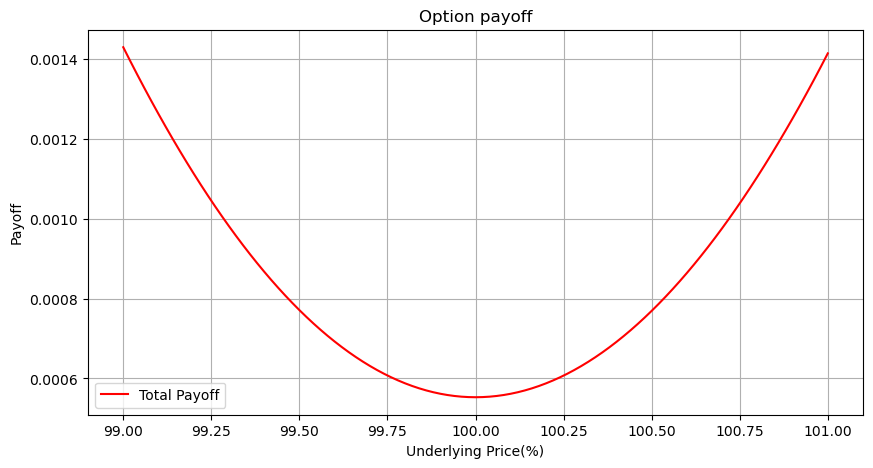

In [114]:
plimit,N=0.01,100 # 10%

# 가격의 최소값과 최대값을 계산
min_price = S0 * (1 - plimit)
max_price = S0 * (1 + plimit)

# min_price와 max_price 사이에서 N개의 가격을 균등하게 생성
prices = np.linspace(min_price, max_price, N+1)

# options
options = np.array([['p',1,100,1,0.05,0.3],
                    ['p',-1,100,1.1,0.05,0.33],
                   ])

M=len(options) # 옵션의 개수


# payoff 저장공간
opt_values = np.zeros([M, N+1])  # 옵션 가격을 저장할 배열
opt_payoff = np.zeros([M, N+1])  # 옵션 페이오프를 저장할 배열
delta_payoff = np.zeros([M, N+1])  # 델타 페이오프를 저장할 배열
total_payoff = np.zeros([M, N+1])  # 전체 페이오프를 저장할 배열

for m in range(M):
    if options[m][0] == 'p':
        buysell = options[m][1].astype(float)
        K, T, r, sigma = options[m][2:].astype(float)  # 숫자로 변환
        
        # 옵션 가격 및 그리스 계산
        opt0 = BS.bs_put(S0, K, T, r, sigma)
        theta = BS.put_theta(S0, K, T, r, sigma)
        delta = BS.put_delta(S0, K, T, r, sigma)
        print(theta,delta)
        
        # 가격대별로 옵션 가격 계산
        for i, s in enumerate(prices):
            opt_values[m, i] = BS.bs_put(s, K, T, r, sigma)
        
        if buysell == 1: # 옵션매수이면
            # delta_payoff 계산
            delta_payoff[m,:] = (prices - S0) * (-delta) 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = opt_values[m, :] - opt0 + theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]
        elif buysell == -1: # 옵션매도이면
            # delta_payoff 계산
            delta_payoff[m,:] =  (prices - S0) * delta 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = - (opt_values[m, :] - opt0) - theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]

    elif options[m][0] == 'c':
        buysell = options[m][1].astype(float)
        K, T, r, sigma = options[m][2:].astype(float)  # 숫자로 변환
        
        # 옵션 가격 및 그리스 계산
        opt0 = BS.bs_call(S0, K, T, r, sigma)
        theta = BS.call_theta(S0, K, T, r, sigma)
        delta = BS.call_delta(S0, K, T, r, sigma)
        print(theta,delta)
        
        # 가격대별로 옵션 가격 계산
        for i, s in enumerate(prices):
            opt_values[m, i] = BS.bs_call(s, K, T, r, sigma)
        
        if buysell == 1: # 옵션매수이면
            # delta_payoff 계산
            delta_payoff[m,:] = (prices - S0) * (-delta) 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = opt_values[m, :] - opt0 + theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]
        elif buysell == -1: # 옵션매도이면
            # delta_payoff 계산
            delta_payoff[m,:] =  (prices - S0) * delta 
        
            # 옵션 페이오프 계산
            opt_payoff[m, :] = - (opt_values[m, :] - opt0) - theta
            total_payoff[m, :] = delta_payoff[m, :] + opt_payoff[m, :]

plt.figure(figsize=(10, 5))
plt.plot(prices, np.sum(total_payoff,axis=0), 'r', label='Total Payoff')
plt.xlabel('Underlying Price(%)')
plt.ylabel('Payoff')
plt.legend()
plt.title("Option payoff")
plt.grid(True)
plt.show()


In [118]:
# pip install hst_funcs 로 패키지 설치
from hst_funcs.finanace.Equity import BS

# 파라미터 설정
S0 = 100 # 기초자산현재가 
K = 110 # 행사가격
T = 1.0 # 옵션만기 (in years)
r = 0.05 # 무위험이자율(%)
sigma = 0.8 # 기초자산의 년변동성 (80%)

# 콜옵션의 가격
BS.bs_call(S0, K, T, r, sigma)

29.53547239328031

In [119]:
# Call spread 가격
K1,K2=120,140
BS.bs_call(100,K1,1,0.05,0.8)-BS.bs_call(100,K2,1,0.05,0.85)

2.8343738679813164